## Initialization

In [2]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [3]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 200517.73350671504
C6 190000.0
beta (a0) 525.3927746085943
E_beta (K) 2.852507331186637e-06
tau_beta (s) 1.6824646316466855e-05


In [4]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.76         # in terms of E6
num_resonances = 400        # should be odd
rrkm = 2 * np.pi / mean_spacing  # rrkm in terms of tau
print(1 / (mean_spacing / 2 / np.pi))
print(rrkm)

0.06729858526586742
93.36281412688626
93.36281412688626


In [6]:
L = (temp / E_beta / c6) ** (1 / 6) 
print(L) # distance (in atomic units) when energy of potential is equal to temperature
print(L / beta)

8.73042048011514
0.01661694051011475


In [105]:
length = 2 # cutoff distance (in beta)

mean_x = 10
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
print(mean_coupling_strength)
# find positive time delay

def get_spectrum():
    while True:
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
        max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = None
        break

        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
        
        if time_delay > rrkm:
            break
    return energy_GOE_mat, W_mat, x_actual, time_delay

energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()
print(time_delay)

0.26112779087244775
None


In [129]:
hbar = 1
std_k = np.sqrt(temp) / 10
std_x = 1 / std_k
x0 = 100
k0 = 1
print(std_k)
print(length / k0)

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


0.08717797887081347
2.0


(999,)


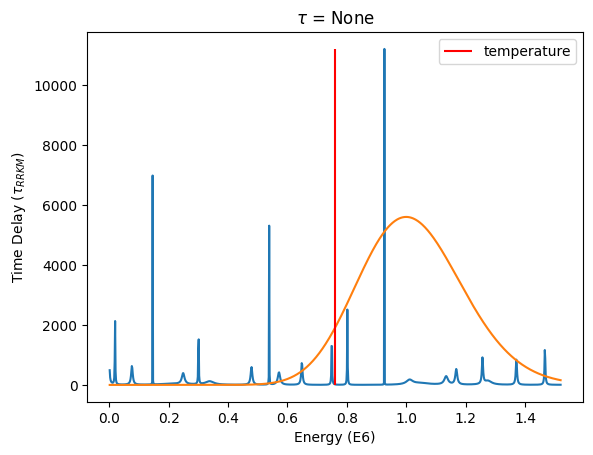

In [130]:
energy_grid = np.linspace(0, 2 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2)
plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.show()

In [124]:
import pickle 

data = {}

index = 100
time_min = 50

for momentum in np.arange(1.0, 1.1, 0.05):
    k0 = momentum.item()

    xs = np.linspace(-100, 1300, 700)
    dx = xs[1] - xs[0]

    ps = np.linspace(k0 - 5 * std_k, k0 + 5 * std_k, 500)
    dp = ps[1] - ps[0]
    ps = ps.reshape((len(ps), 1))

    maxt = (200 / k0 / 2) * 5
    ts = np.linspace(0, maxt, 1200)
    dt = ts[1] - ts[0]

    r1 = lambda k : np.exp(-1j * 2 * k * length) #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
    psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])

    expected_delay = []
    total_percentage = []

    for i in range(500):
        energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()

        r2 = lambda k : np.exp(-1j * 2 * k * length) * np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))
        psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])
        if np.sum(np.abs(psi1[1199][100:]) ** 2 * dx).item() < 0.97:
            print("Not All of Wave")

        flux = []

        for time_index in range(time_min, 1200):
            flux.append(np.sum(np.abs(psi2[time_index][index:]) ** 2 * dx).get())

        flux = np.array(flux)
        total_percentage.append(flux[-1].item())

        pdf = flux.copy()
        for i in range(len(pdf) - 1, 0, -1):
            pdf[i] -= pdf[i - 1]
        expected_value = np.sum(pdf * ts[time_min:]).item()
        expected_delay.append(expected_value) 

        # plt.plot(ts[time_min:].get(), flux.get())
        # plt.plot(ts[time_min:].get(), pdf.get())
        # plt.show()

    save_dict = {"expected value": expected_delay, "percentage": total_percentage}
    data[k0] = save_dict
    break
    
# with open("RbCs/wavepacket/sweeep_10.pkl", "wb") as f:
#     pickle.dump(data, f)

# print(data)

In [107]:
data[0.6]["expected value"][:5]

[233.7967711644568,
 235.13739584464867,
 250.20883143475046,
 250.9420109144803,
 249.38993887346933]

In [20]:
index = 100
print(xs[index])
print(dx)
time_min = 50
print(ts[time_min])
print(dt)

100.28612303290414
2.002861230329046
50.0417014178482
1.0008340283569641


In [97]:
import pickle 
with open("RbCs/wavepacket/sweeep_nores.pkl", "rb") as f:
    data_nores = pickle.load(f)
for key in data_nores:
    print(data_nores[key]["expected value"][0], 100 / key)

171.4184795287532 166.66666666666669
158.7164943977259 153.84615384615384
147.46201919743606 142.85714285714286
137.54814274018113 133.33333333333334
128.8165498926869 125.0
121.10091134073761 117.64705882352942
114.25047245867232 111.11111111111111
108.1337093815468 105.26315789473685
102.64090021371621 100.0
97.68213263369863 95.23809523809524
93.18321106683487 90.9090909090909


In [122]:
with open("RbCs/wavepacket/sweeep_10.pkl", "rb") as f:
    data_old = pickle.load(f)

0.9081061042855597
Expected 139.37926843480145
Delay 39.379268434801446


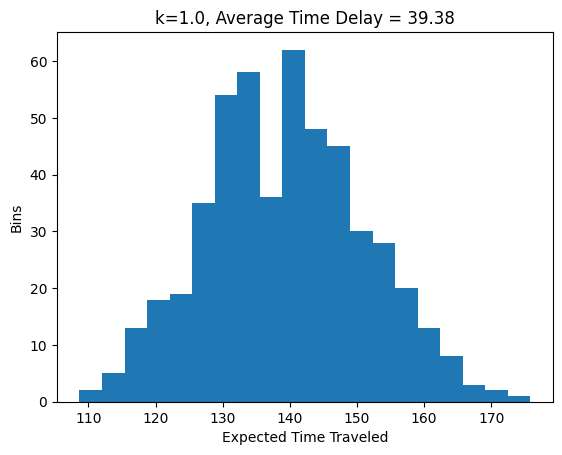

In [125]:
for key in data:
    expected_delay = np.array(data[key]["expected value"])
    total_percentage = data[key]["percentage"]
    print(min(total_percentage))

    print("Expected", np.mean(expected_delay))
    print("Delay", np.mean(expected_delay) - 100 / key)
    delay = np.mean(expected_delay) - 100 / key
    plt.hist(expected_delay.get(), bins=20)
    plt.xlabel("Expected Time Traveled")
    plt.ylabel("Bins")
    plt.title(f"k={key}, Average Time Delay = {round(delay.item(), 2)}")
    plt.savefig(f"RbCs/wavepacket/hist_{key}.pdf")
    plt.show()

0.9347088992371733
Expected 230.89067714717368
Delay 64.22401048050699


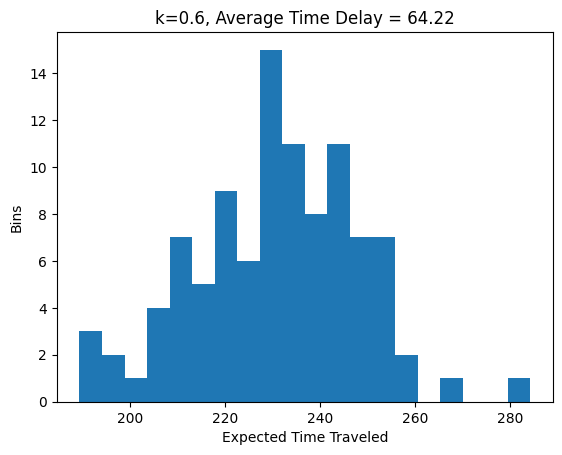

0.9424396100789013
Expected 212.83697977918823
Delay 58.99082593303439


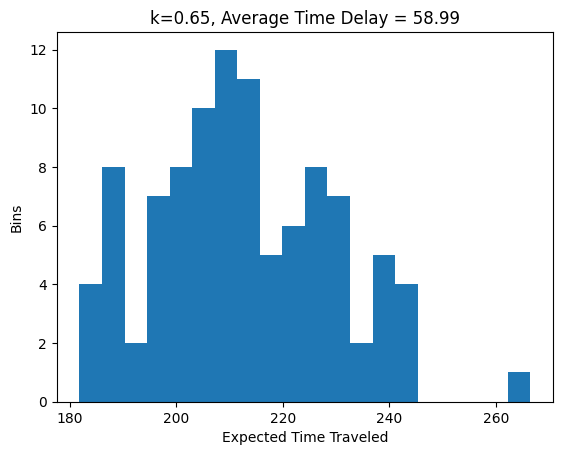

0.9328300280483818
Expected 197.37331558973503
Delay 54.51617273259217


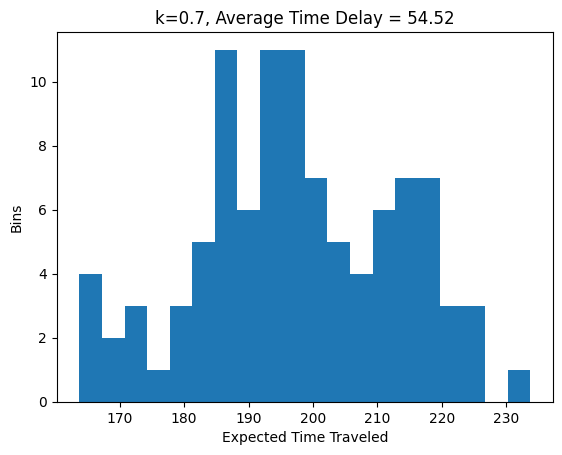

0.9356158233516199
Expected 185.0527098247846
Delay 51.71937649145127


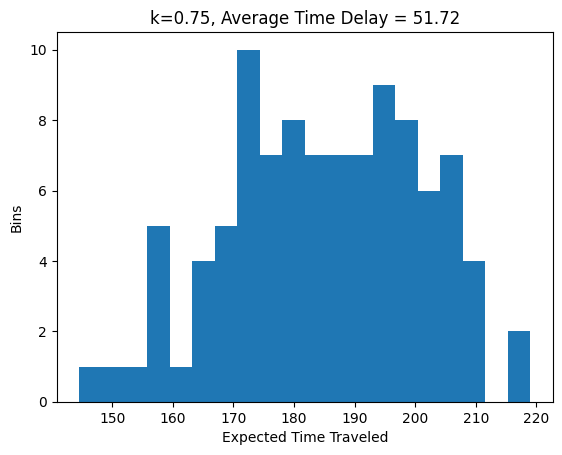

0.932599405549208
Expected 177.15476619589987
Delay 52.15476619589987


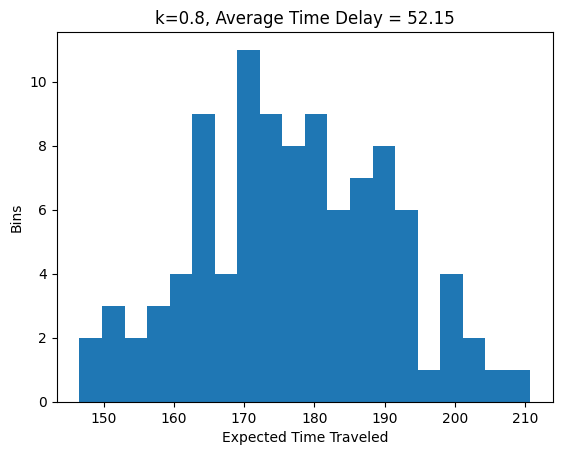

0.932713433131039
Expected 165.09972135700644
Delay 47.452662533477024


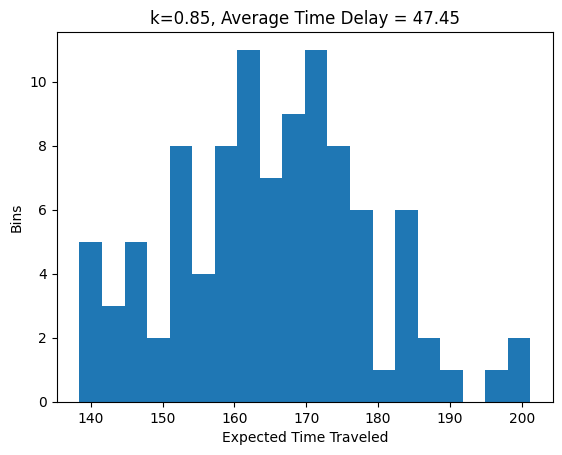

0.9180731816902562
Expected 152.0890320990961
Delay 40.97792098798499


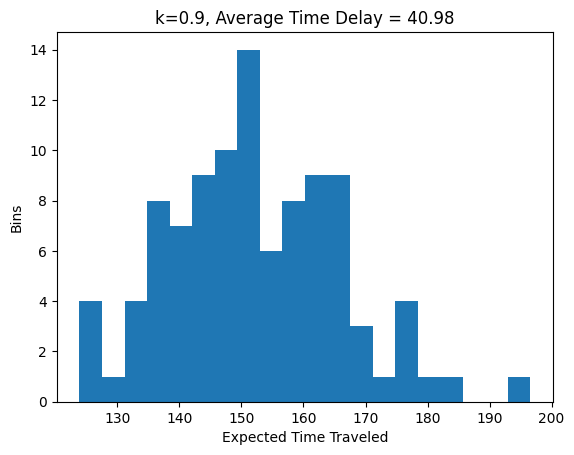

0.9242027028667648
Expected 149.71965599259912
Delay 44.456498097862266


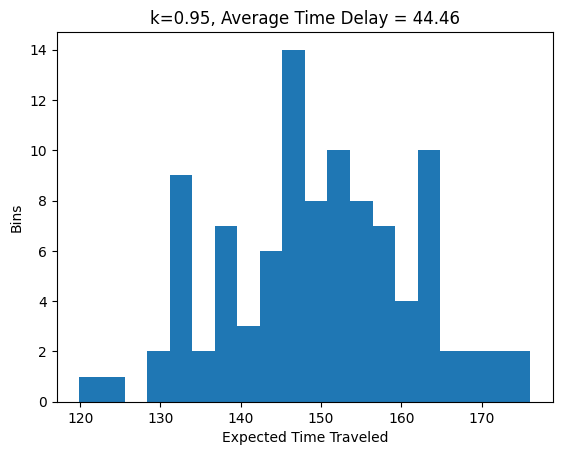

0.911028637017014
Expected 140.24768276792963
Delay 40.24768276792963


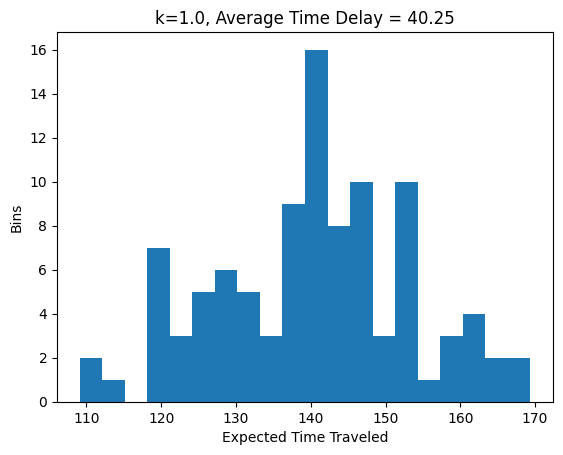

0.9212620028692333
Expected 132.7558771344867
Delay 37.517781896391455


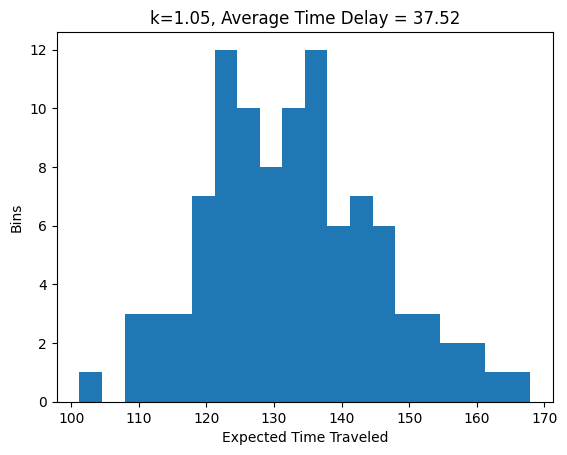

0.9213255874439396
Expected 127.93632049006824
Delay 37.027229580977334


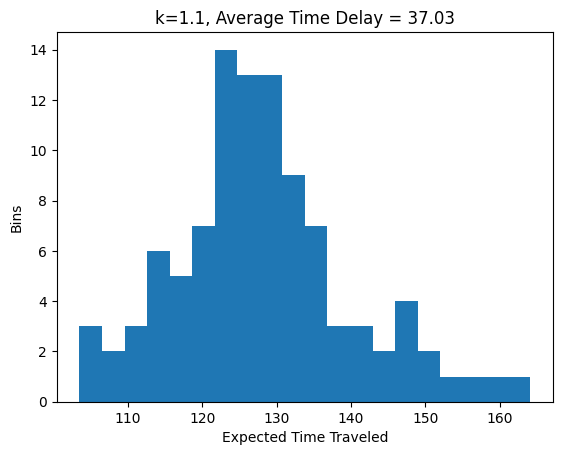

In [126]:
for key in data_old:
    expected_delay = np.array(data_old[key]["expected value"])
    total_percentage = data_old[key]["percentage"]
    print(min(total_percentage))

    print("Expected", np.mean(expected_delay))
    print("Delay", np.mean(expected_delay) - 100 / key)
    delay = np.mean(expected_delay) - 100 / key
    plt.hist(expected_delay.get(), bins=20)
    plt.xlabel("Expected Time Traveled")
    plt.ylabel("Bins")
    plt.title(f"k={key}, Average Time Delay = {round(delay.item(), 2)}")
    plt.savefig(f"RbCs/wavepacket/hist_{key}.pdf")
    plt.show()

Half Life 150.30325271059215
Expected 169.71971266818997
RRKM 93.36281412688626


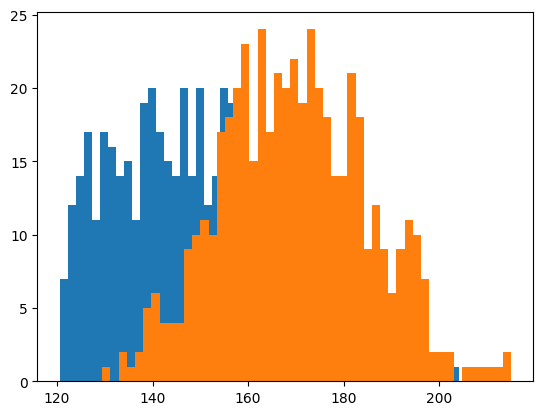

In [33]:
half_life = np.array(data["half life"])
expected_delay = np.array(data["expected value"])
total_percentage = data["percentage"]

print("Half Life", np.mean(half_life))
plt.hist(half_life.get(), bins=50)

print("Expected", np.mean(expected_delay))
plt.hist(expected_delay.get(), bins=50)

print("RRKM", rrkm)

## Together

In [5]:
psis = [psi1, psi2]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs.get(), np.abs(psi[i]).get() ** 2)[0]
    lines.append(line)
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 30
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani

NameError: name 'psi1' is not defined